
# Session 3 — Descriptive Statistics

**Focus:** Mean, Median, Mode, MAD, Variance, Standard Deviation  
**Duration:** ~30–40 minutes

### Learning Goals
- Compute and interpret **mean, median, mode**.
- Compute and interpret **MAD, variance, standard deviation**.
- Understand the **effect of outliers** on center and spread.
- Apply these measures on a **real dataset** (U.S. airline accidents, 1985–2006).


## 0) Setup

In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



## 1) Mean, Median, Mode

We start with a small numeric dataset. Change the values to observe how the **mean**, **median**, and **mode** behave under symmetry vs. skewness.


In [7]:

# Example dataset (edit freely)
data = np.array([15, 20, 25, 30, 35, 15, 20, 34 ,45, 56, 15])

mean = np.mean(data)
median = np.median(data)

#mode
values, counts = np.unique(data, return_counts=True)

# Find the maximum count
max_count = np.max(counts)

# Extract modes
modes = values[counts == max_count]


print(f"Mean:   {mean:.3f}")
print(f"Median: {median:.3f}")
print("Mode(s):", modes)


Mean:   28.182
Median: 25.000
Mode(s): [15]



## 2) MAD, Variance, and Standard Deviation

- **MAD (mean absolute deviation)**:
- **Variance (sample)**:
- **Standard deviation (sample)**:


In [9]:

# MAD
mad = np.mean(np.abs(data - mean))

# Sample variance and standard deviation
var_sample = np.var(data, ddof=1) #ddof=1 to divide by n-1
sd_sample = np.std(data, ddof=1)

print(f"MAD : {mad:.3f}")
print(f"Sample Variance:      {var_sample:.3f}")
print(f"Sample Std Dev:       {sd_sample:.3f}")


MAD : 10.744
Sample Variance:      180.564
Sample Std Dev:       13.437



## 3) Effect of an Outlier

Add an extreme value and see how **mean**, **median**, and **SD** react.


Central tendency:
Mean (orig): 28.18    Mean (outlier): 34.17
Median (orig): 25.00  Median (outlier): 27.50
SPREAD:
SD (orig): 13.44   SD (outlier): 24.37


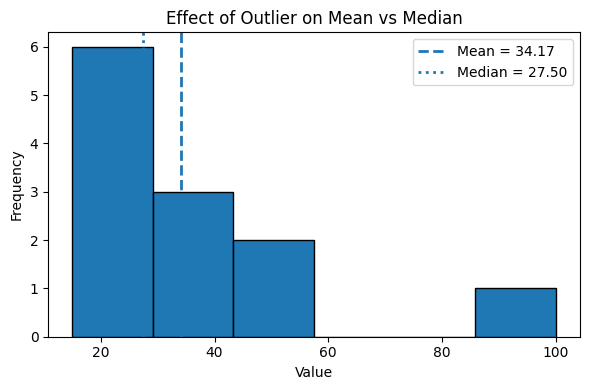

In [10]:
#add an outlier to data


data_outlier = np.append(data, 100)

print("Central tendency:")
print(f"Mean (orig): {np.mean(data):.2f}    Mean (outlier): {np.mean(data_outlier):.2f}")
print(f"Median (orig): {np.median(data):.2f}  Median (outlier): {np.median(data_outlier):.2f}")

print("SPREAD:")
print(f"SD (orig): {np.std(data, ddof=1):.2f}   SD (outlier): {np.std(data_outlier, ddof=1):.2f}")

# Visualization
plt.figure(figsize=(6,4))
plt.hist(data_outlier, bins=6, edgecolor="black")
plt.axvline(np.mean(data_outlier), linestyle="--", linewidth=2, label=f"Mean = {np.mean(data_outlier):.2f}")
plt.axvline(np.median(data_outlier), linestyle=":", linewidth=2, label=f"Median = {np.median(data_outlier):.2f}")
plt.title("Effect of Outlier on Mean vs Median")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()



## 4) Real Dataset — U.S. Airline Accidents (1985–2006)

We compute descriptive statistics for the **number of accidents per year** and visualize the series.


    Year  Accidents
0   1985          4
1   1986          2
2   1987          4
3   1988          3
4   1989         11
5   1990          6
6   1991          4
7   1992          4
8   1993          1
9   1994          4
10  1995          2
11  1996          3
12  1997          3
13  1998          1
14  1999          2
15  2000          2
16  2001          6
17  2002          0
18  2003          2
19  2004          1
20  2005          3
21  2006          2

Descriptive statistics (accidents/year):
Mean:   3.18
Median: 3.00
Mode:   [2]
SD:     2.32


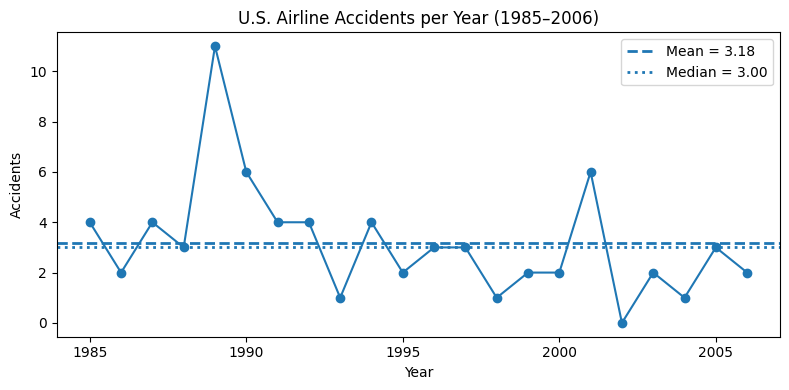

In [14]:

# Years and accidents (22 years)
years = list(range(1985, 2007))
accidents = [4, 2, 4, 3, 11, 6, 4, 4, 1, 4, 2, 3, 3, 1, 2, 2, 6, 0, 2, 1, 3, 2]

df = pd.DataFrame({"Year": years, "Accidents": accidents})

mean_acc = np.mean(df["Accidents"])
median_acc = np.median(df["Accidents"])
sd_acc = np.std(df["Accidents"], ddof=1)

#mode
values, counts = np.unique(accidents, return_counts=True)
# Find the maximum count
max_count = np.max(counts)
# Extract modes
mode_acc = values[counts == max_count]


print(df)
print("\nDescriptive statistics (accidents/year):")
print(f"Mean:   {mean_acc:.2f}")
print(f"Median: {median_acc:.2f}")
print(f"Mode:   {mode_acc}")
print(f"SD:     {sd_acc:.2f}")

# Line plot — one figure
plt.figure(figsize=(8,4))
plt.plot(df["Year"], df["Accidents"], marker="o")
plt.axhline(mean_acc, linestyle="--", linewidth=2, label=f"Mean = {mean_acc:.2f}")
plt.axhline(median_acc, linestyle=":", linewidth=2, label=f"Median = {median_acc:.2f}")
plt.title("U.S. Airline Accidents per Year (1985–2006)")
plt.xlabel("Year")
plt.ylabel("Accidents")
plt.legend()
plt.tight_layout()
plt.show()
